# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



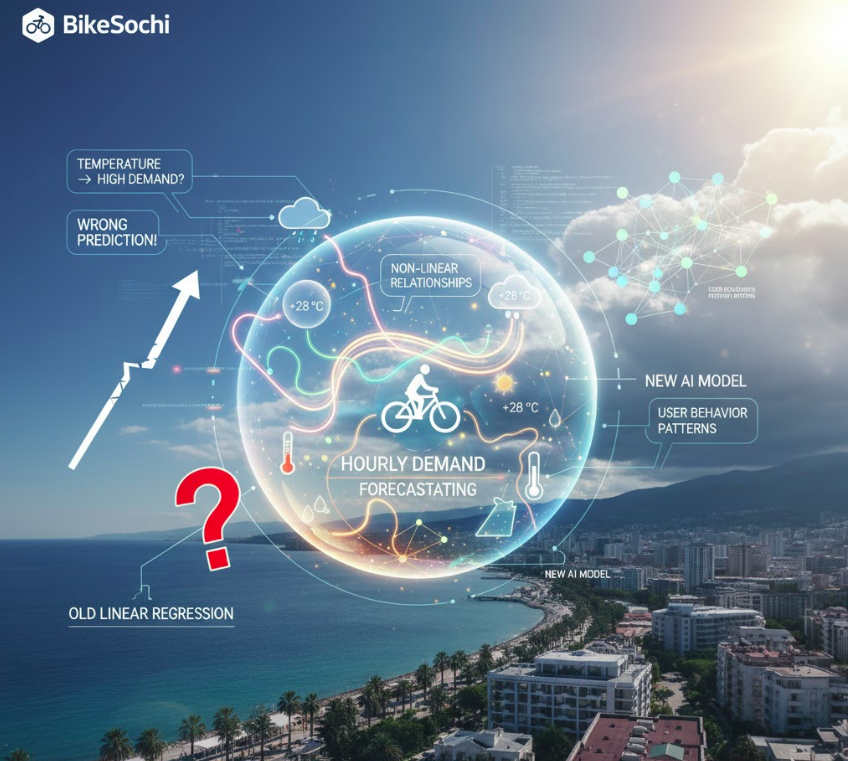

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**

## Загрузка библиотек

In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

# Предобрабока данных
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import joblib
import os
import re
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning) 

path = os.getcwd()
RANDOM_SEED = 555

## Подготовка классов и функций

In [33]:
# Подготавливаем функции визуализации данных и расчета метрик

# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame) -> pd.DataFrame:

    # 1. Приводим названия колонок к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 2. Удаляем спецсимволы, удаляем пробелы по краям: оставляем только буквы, цифры
    # [^a-z0-9_] — всё, что не является латинской буквой, цифрой или подчёркиванием
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', ' ', regex=True).str.strip()
    # 3. Удаляем пробелы, заменяем на _
    df.columns = df.columns.str.replace(r'\s+', '_', regex=True)   
  

    # На случай, если после очистки остались пустые названия — заменяем их на col_N
    empty_cols = df.columns == ''
    if empty_cols.any():
        empty_indices = df.columns[empty_cols].index
        for i, idx in enumerate(empty_indices):
            df.columns.values[i] = f'col_{i}'

    # 3. Оптимизация типов для float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 4. Оптимизация типов для int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

# =========================
# bar chart

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    fig, axes = plt.subplots(nrows=len(feature_list), ncols=1, figsize=(12, 2 * len(feature_list)))

    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i], vert=False)
        axes[i].set_title(f'Boxplot: {feature}')
        axes[i].tick_params(axis='x', labelrotation=0)
        axes[i].grid(axis='x', alpha=0.5) 

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# =========================
# phik heatmap
def phik_coolwarm_matrix(df, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()

## Загрузка данных

In [3]:
df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

In [4]:
df_train.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [5]:
df_test.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


In [6]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

In [7]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

In [8]:
df_train.duplicated().sum()

np.int64(0)

In [9]:
df_test.duplicated().sum()

np.int64(0)

In [10]:
show_missing_stats(df_train)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,0.0375
Rainfall(mm),262,0.0374
Visibility (10m),259,0.0370
Humidity(%),250,0.0357
Solar Radiation (MJ/m2),210,0.0300
Wind speed (m/s),210,0.0300


In [11]:
show_missing_stats(df_test)

,Кол-во пропусков,Доля пропусков
Humidity(%),72,0.0411
Visibility (10m),72,0.0411
Rainfall(mm),64,0.0365
Snowfall (cm),61,0.0348
Solar Radiation (MJ/m2),52,0.0297
Wind speed (m/s),52,0.0297


In [15]:
df_train_optimized = optimize_dataframe(df_train)
df_test_optimized = optimize_dataframe(df_test)

In [16]:
df_train_optimized.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float32
 1   humidity                  6758 non-null   float32
 2   wind_speed_m_s            6798 non-null   float32
 3   visibility_10m            6749 non-null   float32
 4   dew_point_temperature     7008 non-null   float32
 5   solar_radiation_mj_m2     6798 non-null   float32
 6   rainfall_mm               6746 non-null   float32
 7   snowfall_cm               6745 non-null   float32
 8   seasons                   7008 non-null   str    
 9   holiday                   7008 non-null   str    
 10  functioning_day           7008 non-null   str    
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_period_night  

In [17]:
df_test_optimized.info()

<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               1752 non-null   float32
 1   humidity                  1680 non-null   float32
 2   wind_speed_m_s            1700 non-null   float32
 3   visibility_10m            1680 non-null   float32
 4   dew_point_temperature     1752 non-null   float32
 5   solar_radiation_mj_m2     1700 non-null   float32
 6   rainfall_mm               1688 non-null   float32
 7   snowfall_cm               1691 non-null   float32
 8   seasons                   1752 non-null   str    
 9   holiday                   1752 non-null   str    
 10  functioning_day           1752 non-null   str    
 11  time_period_evening       1752 non-null   bool   
 12  time_period_late_evening  1752 non-null   bool   
 13  time_period_morning       1752 non-null   bool   
 14  time_period_night  

In [18]:
# Распределеим признаки по группам: числовые, категориальные, бинарные
numerical_features = df_train_optimized.select_dtypes(include='float').columns.to_list()
categorical_features = df_train_optimized.select_dtypes(include='str').columns.to_list()
binary_features = df_train_optimized.select_dtypes(include='bool').columns.to_list()

print(numerical_features)
print(categorical_features)
print(binary_features)

['temperature', 'humidity', 'wind_speed_m_s', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mj_m2', 'rainfall_mm', 'snowfall_cm']
['seasons', 'holiday', 'functioning_day']
['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']


# **Часть 1: Базовая модель**

In [16]:
path_to_file = '/datasets/baseline_linear_regression_pipeline.joblib'
loaded_model = joblib.load(path_to_file)
y_pred = loaded_model.predict(df_test.drop(columns='Rented Bike Count'))

In [18]:
base_model_scores = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}
base_model_scores

{'RMSE': 411.4544584757228,
 'MAE': 312.53129792458947,
 'R2': 0.5862925700677417}

# **Часть 2: Улучшение модели — KNN и Decision Tree**

## Шаг 1. Изучение постановки задачи: EDA (Exploratory Data Analysis)

### 1. Распределение целевой переменной Rented Bike Count

In [19]:
df_train_optimized['rented_bike_count'].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: rented_bike_count, dtype: float64

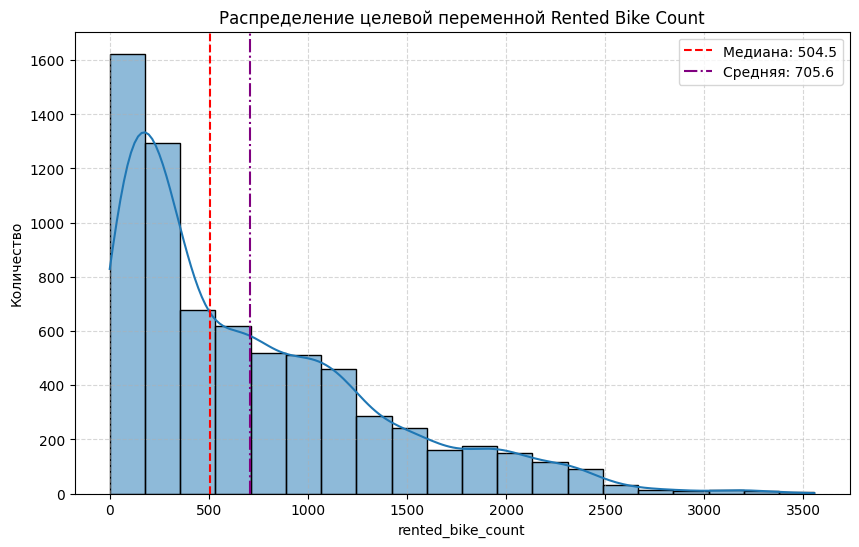

In [23]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=df_train_optimized, x='rented_bike_count', bins=20, ax=ax, kde=True)
plt.title('Распределение целевой переменной Rented Bike Count')
plt.ylabel('Количество')
plt.grid(True, linestyle='--', alpha=0.5)
median_val = df_train_optimized['rented_bike_count'].median()
mean_val = df_train_optimized['rented_bike_count'].mean()
plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
plt.legend()
plt.show()

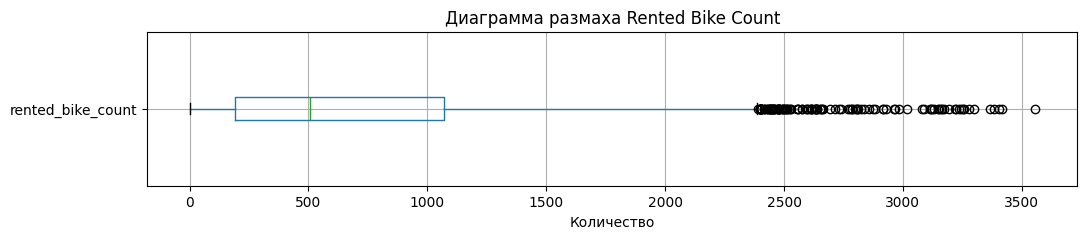

In [24]:
# Строим диаграмму размаха методом boxplot()
boxplot = df_train_optimized.boxplot(column='rented_bike_count',
                    vert=False, 
                    figsize=(12, 2))

# Добавляем заголовок и метку оси X
boxplot.set_title('Диаграмма размаха Rented Bike Count')
boxplot.set_xlabel('Количество')

plt.show()

### 2. Сезонное распределение целевой переменной Rented Bike Count

In [25]:
df_train_optimized.groupby('seasons', as_index=False).agg(rented_bike_mean=('rented_bike_count', 'mean')).sort_values('rented_bike_mean', ascending=False).round(0)

,seasons,rented_bike_mean
2,Summer,1046.0
0,Autumn,821.0
1,Spring,725.0
3,Winter,226.0


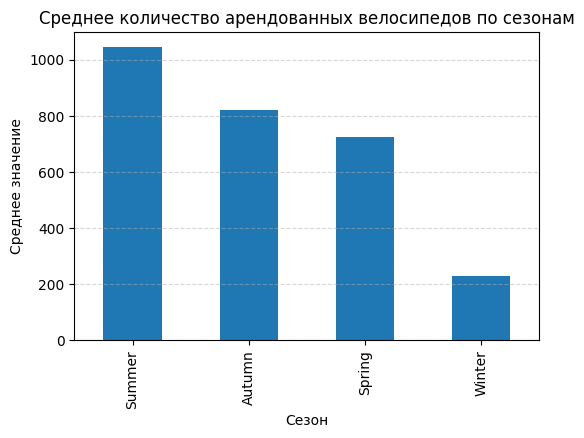

In [26]:
plot_df = (
    df_train
    .groupby('seasons', as_index=False)
    .agg(rented_bike_mean=('rented_bike_count', 'mean'))
    .sort_values('rented_bike_mean', ascending=False)
)

ax = plot_df.plot.bar(x='seasons', y='rented_bike_mean', figsize=(6,4), legend=False)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.title('Среднее количество арендованных велосипедов по сезонам')
plt.ylabel('Среднее значение')
plt.xlabel('Сезон')
plt.show()

### 3. Распределение целевой переменной по праздничным и непраздничным дням

In [27]:
df_train.groupby('holiday', as_index=False).agg(rented_bike_mean=('rented_bike_count', 'mean')).sort_values('rented_bike_mean', ascending=False).round(0)

,holiday,rented_bike_mean
1,No Holiday,716.0
0,Holiday,494.0


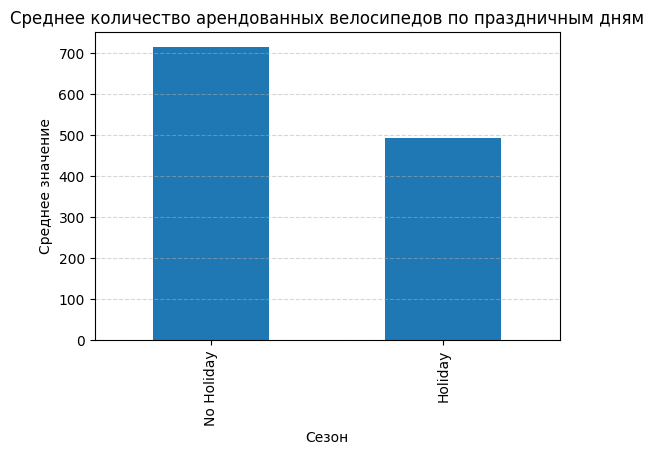

In [28]:
plot_df = (
    df_train
    .groupby('holiday', as_index=False)
    .agg(rented_bike_mean=('rented_bike_count', 'mean'))
    .sort_values('rented_bike_mean', ascending=False)
)

ax = plot_df.plot.bar(x='holiday', y='rented_bike_mean', figsize=(6,4), legend=False)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.title('Среднее количество арендованных велосипедов по праздничным дням')
plt.ylabel('Среднее значение')
plt.xlabel('Сезон')
plt.show()

### 4. Распределение числовых признаков

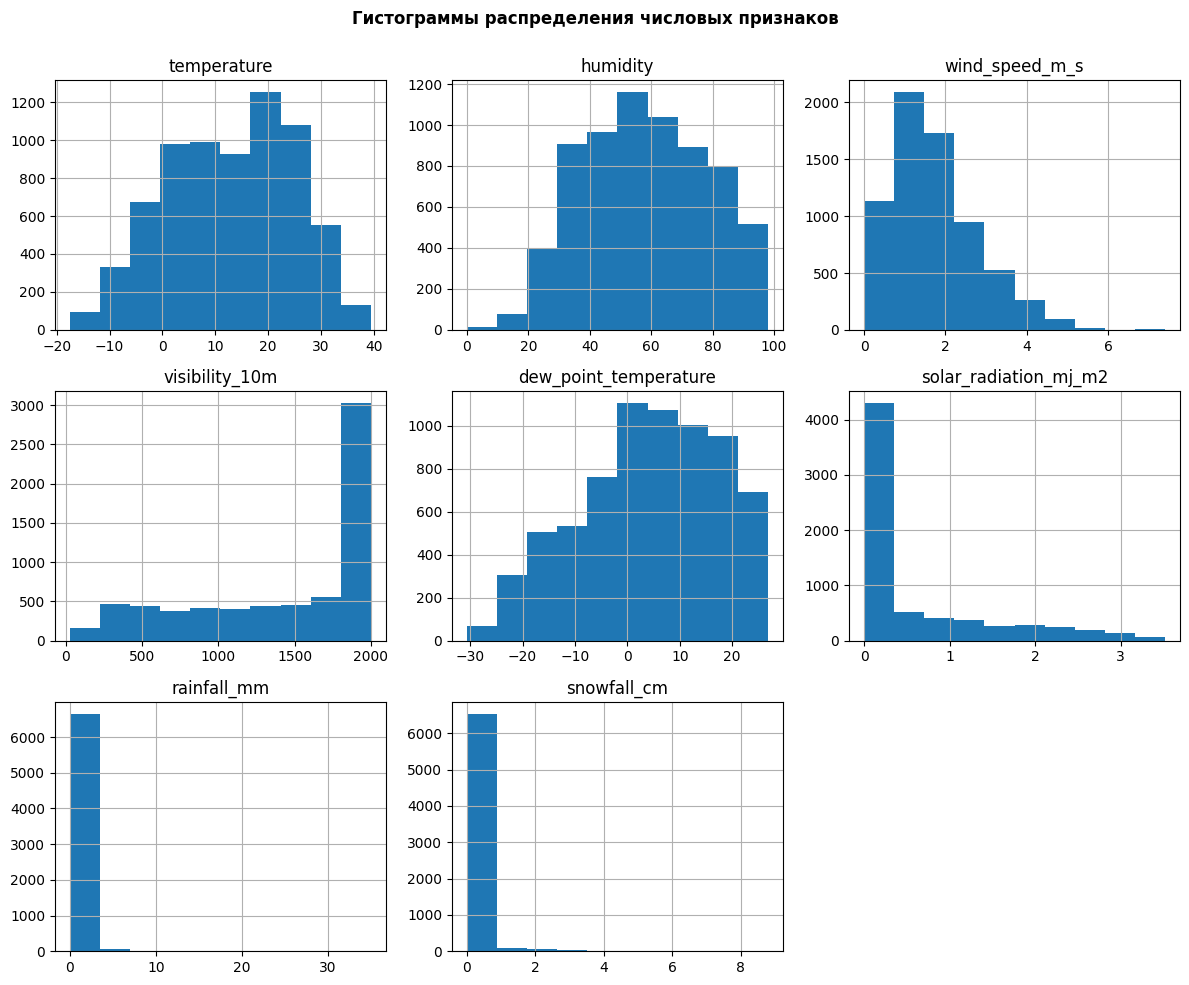

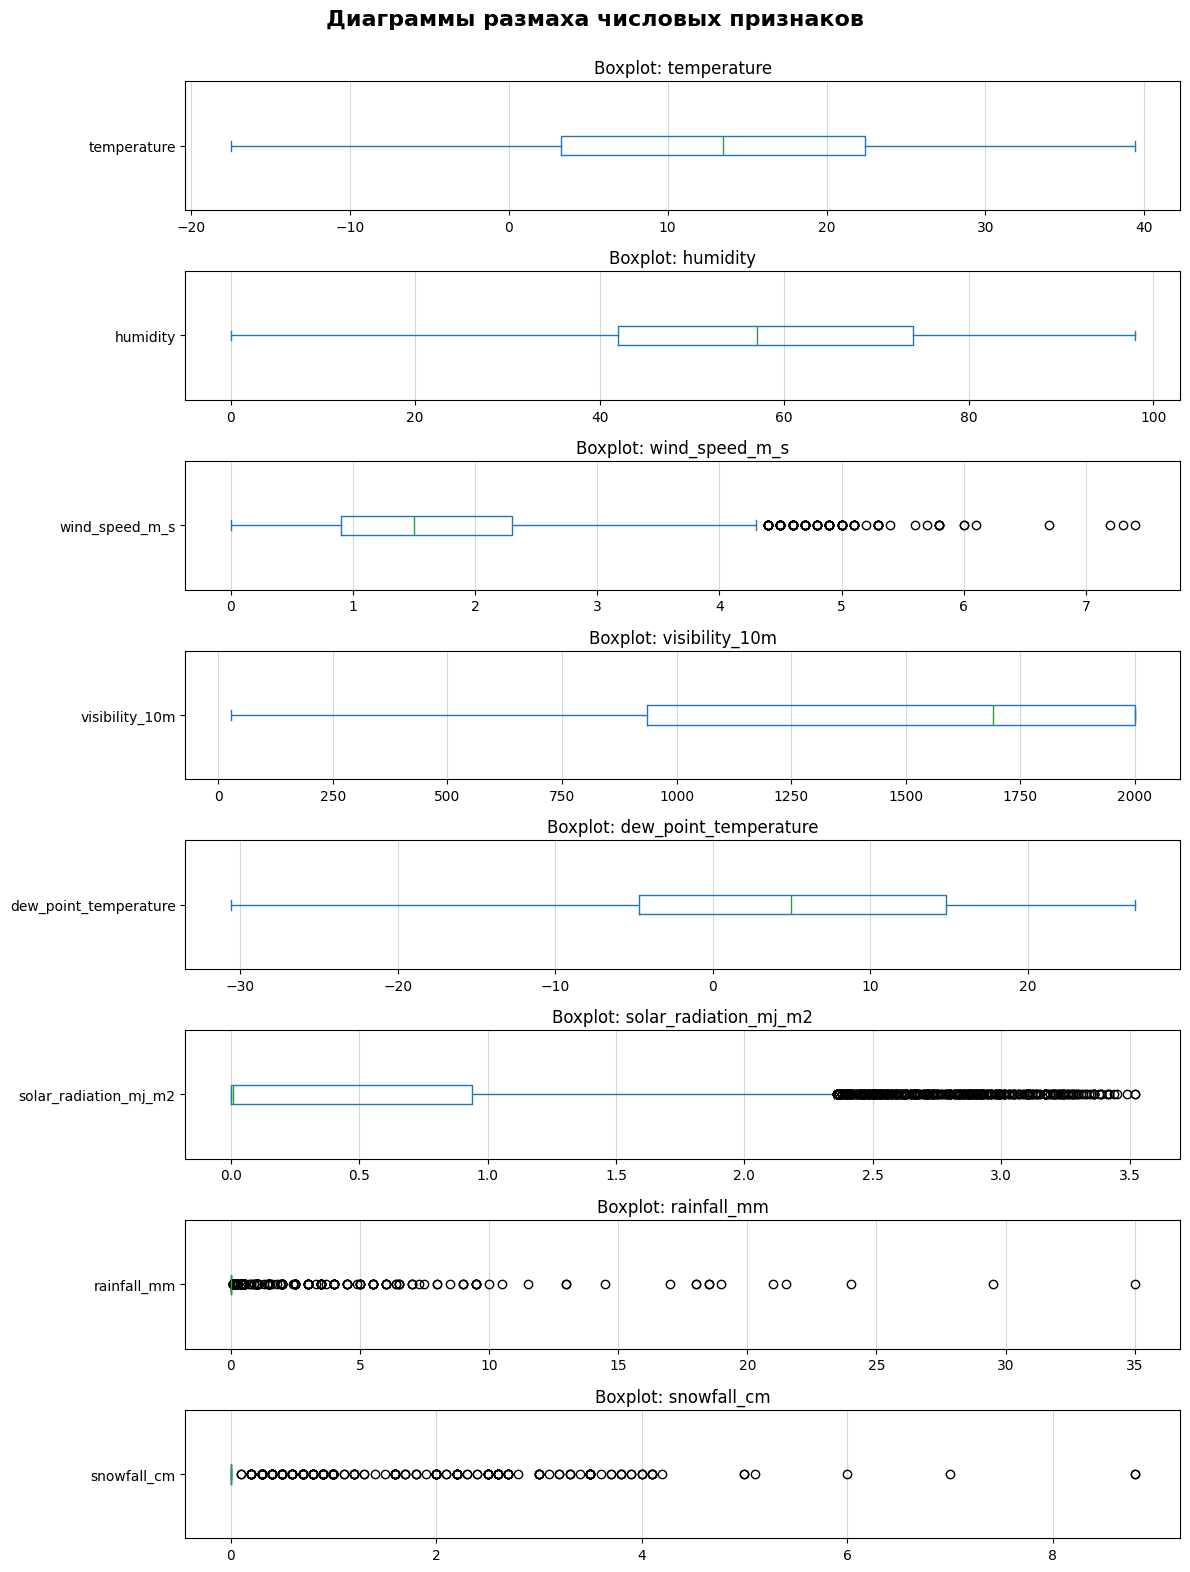

In [31]:
# Посмотрим на количественные признаки них на графиках. 
df_train_optimized[numerical_features].hist(figsize=(12, 10))
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

boxplot_chart(df_train_optimized, numerical_features, diagram_name='Диаграммы размаха числовых признаков')

### 5. Распределение категориальных признаков

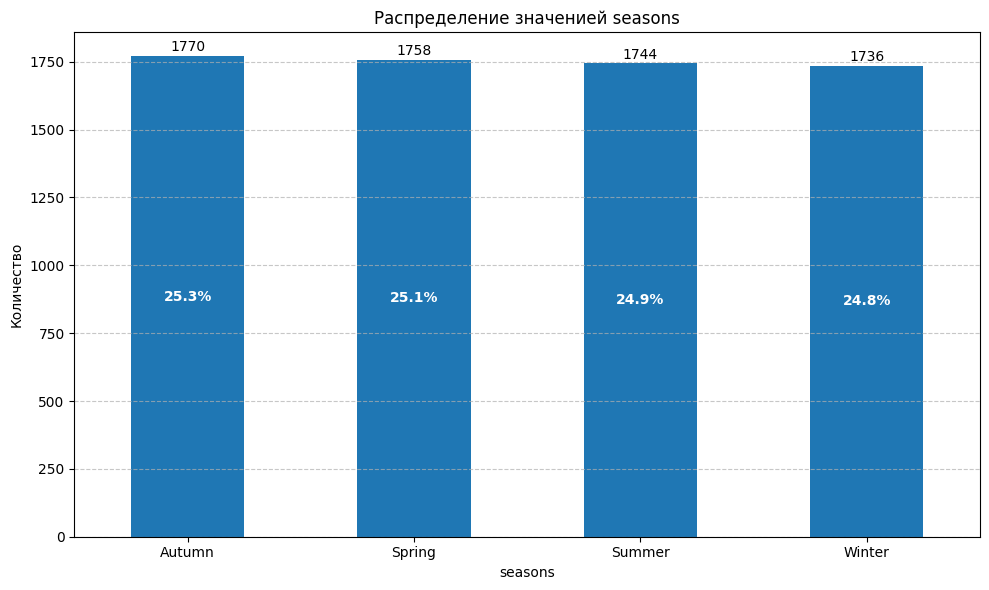

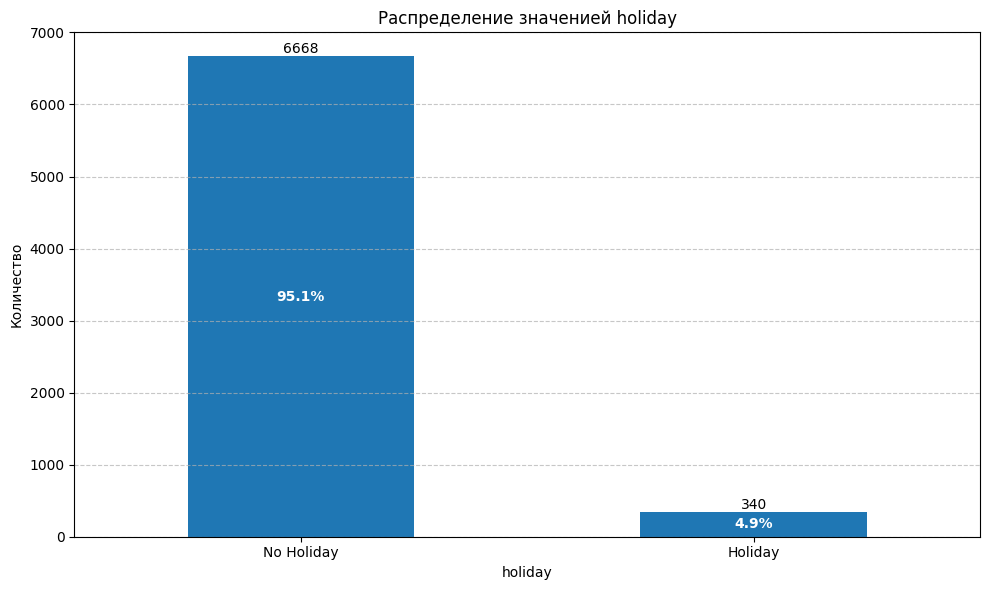

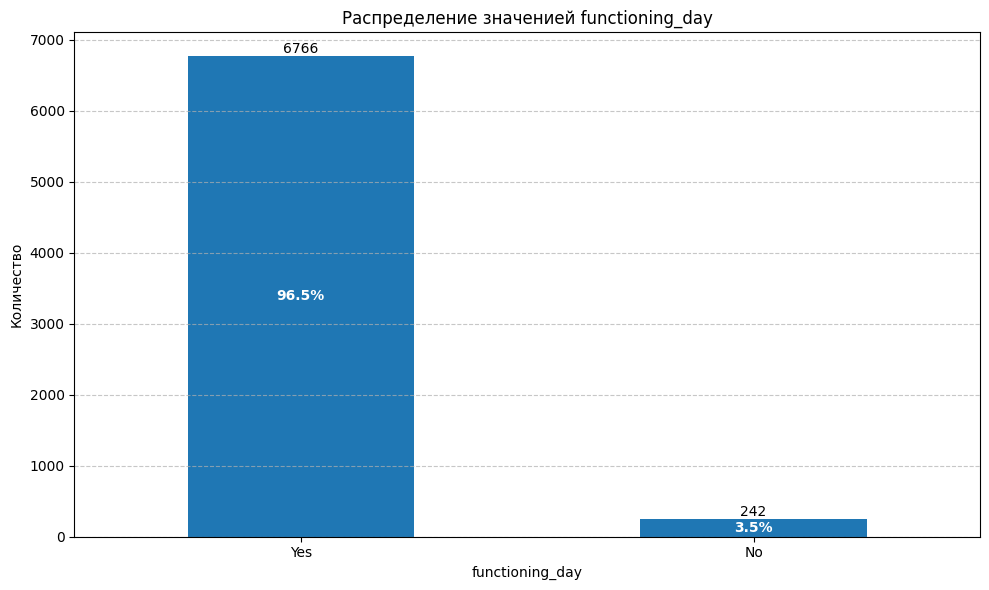

In [34]:
for feature in categorical_features:
    plot_bar_chart(df_train_optimized[feature], figsize=(10,6), xlabel=feature, title=f'Распределение значенией {feature}', top_n=10)

### 6. Распределение бинарных признаков

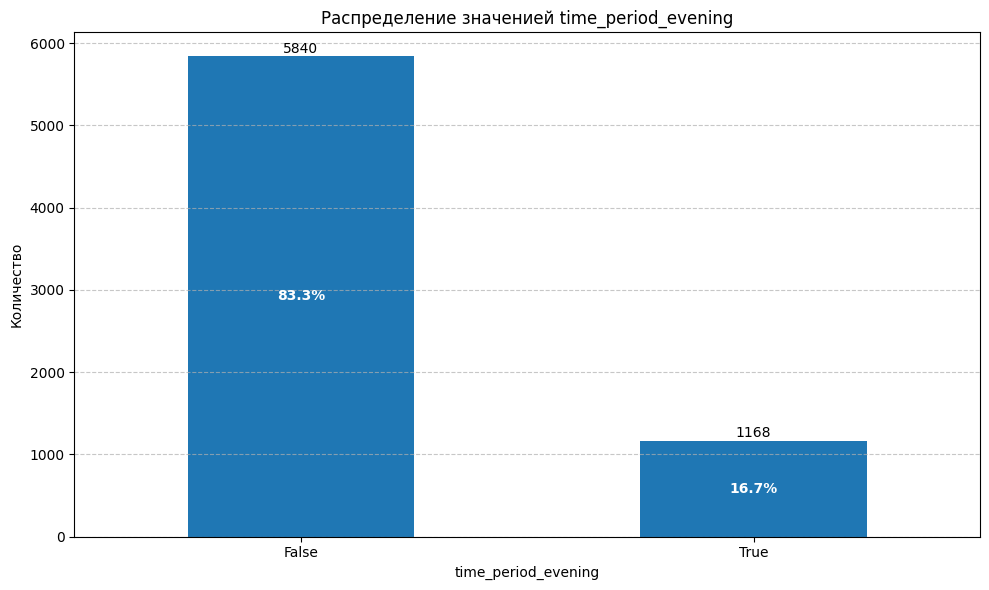

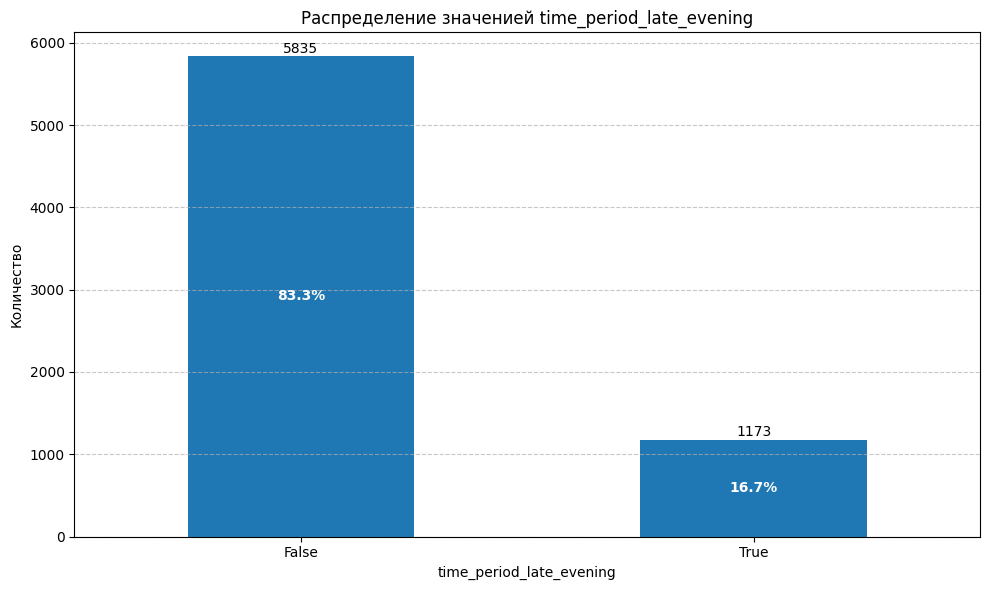

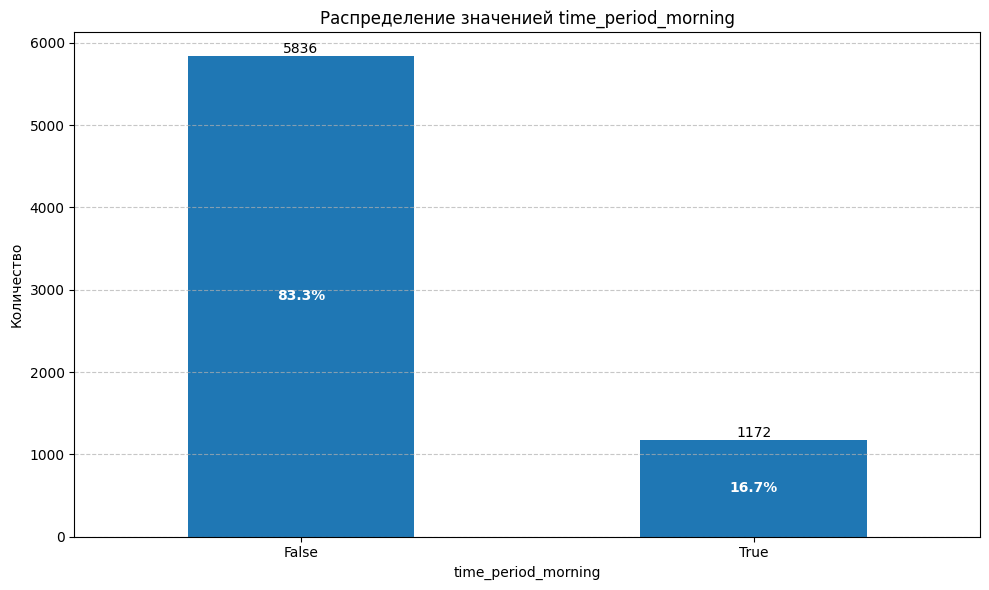

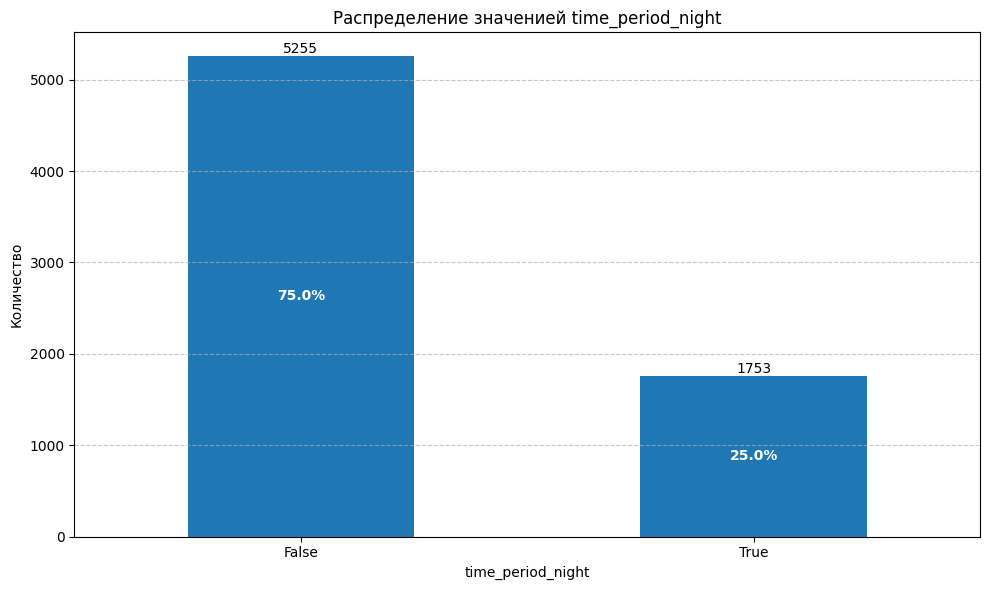

In [35]:
for feature in binary_features:
    plot_bar_chart(df_train_optimized[feature], figsize=(10,6), xlabel=feature, title=f'Распределение значенией {feature}', top_n=10)

### 7. Графики зависимости целевой переменной и числовых признаков

In [76]:
df_train.head()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


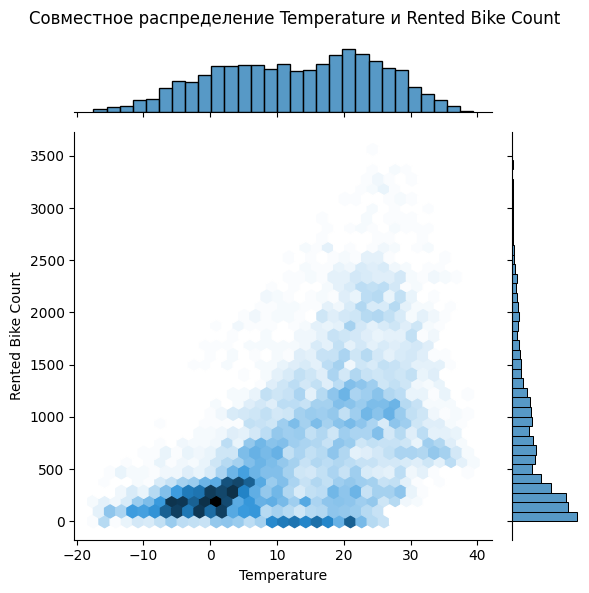

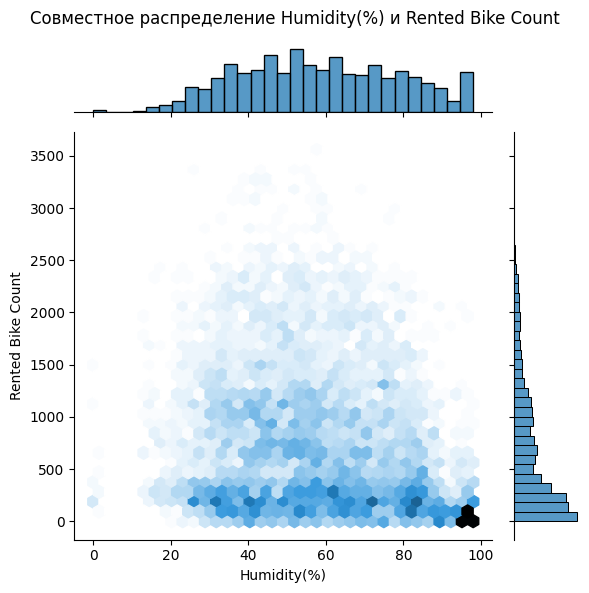

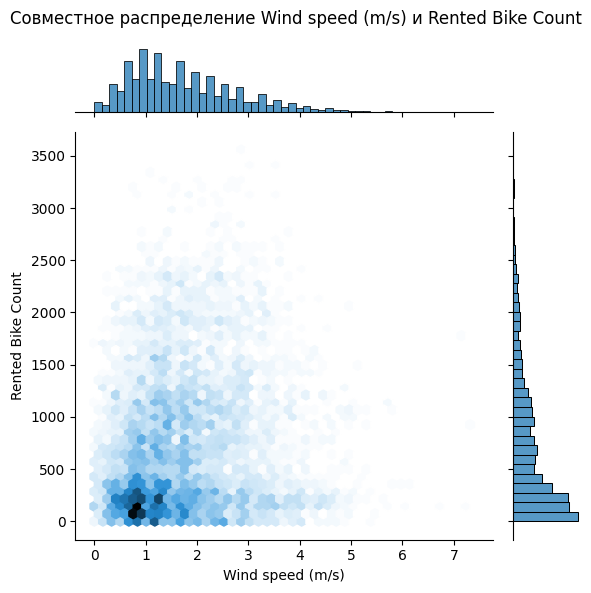

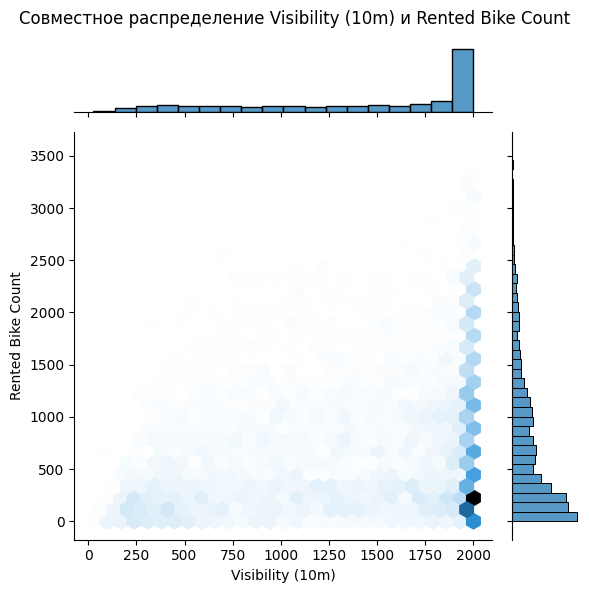

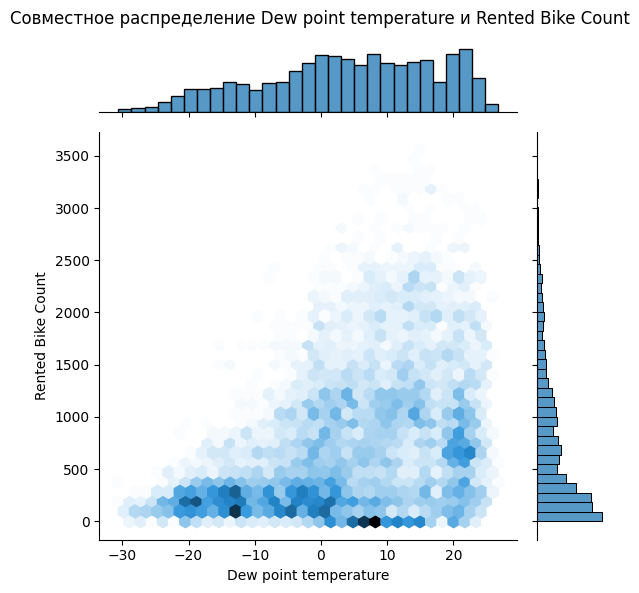

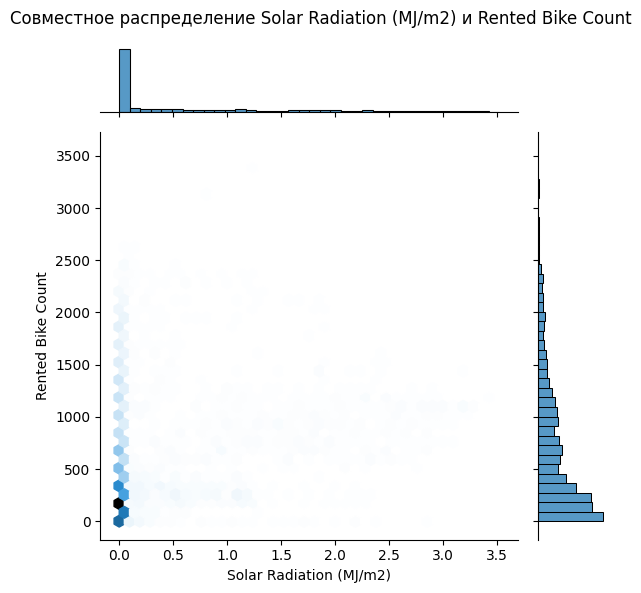

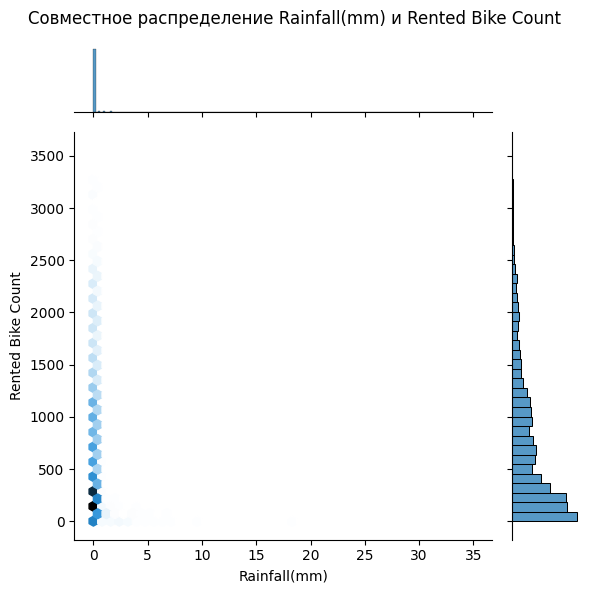

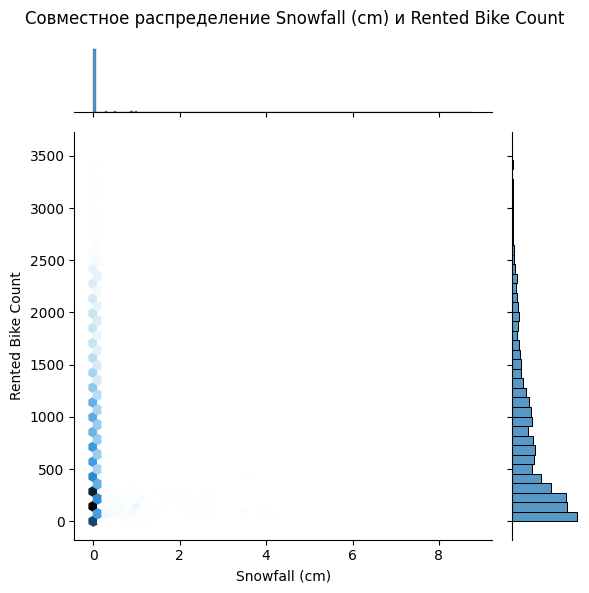

In [ ]:
for feature in numerical_features:
    # Построим график совместного распределения для столбцов `score` и `Balance`
    sns.jointplot(data=df_train, x=feature, y='Rented Bike Count', kind='hex', height=6)

    # Подписываем и отображаем график
    plt.suptitle(f'Совместное распределение {feature} и Rented Bike Count')
    plt.tight_layout()
    plt.show()

### 8. Корреляция между признаками и целевой переменной

In [110]:
df_train[['Rented Bike Count'] + numerical_features].corr(method='pearson').style.background_gradient(cmap='coolwarm')

,Rented Bike Count,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.541478,-0.189910,0.110949,0.197705,0.386701,0.256870,-0.117923,-0.141062
Temperature,0.541478,1.000000,0.157671,-0.035977,0.037286,0.913420,0.356532,0.046772,-0.215239
Humidity(%),-0.189910,0.157671,1.000000,-0.325579,-0.544278,0.533884,-0.460337,0.227664,0.112534
Wind speed (m/s),0.110949,-0.035977,-0.325579,1.000000,0.172726,-0.174702,0.334478,-0.018490,0.004821
Visibility (10m),0.197705,0.037286,-0.544278,0.172726,1.000000,-0.174277,0.151804,-0.159141,-0.118403
Dew point temperature,0.386701,0.913420,0.533884,-0.174702,-0.174277,1.000000,0.099059,0.119519,-0.147413
Solar Radiation (MJ/m2),0.256870,0.356532,-0.460337,0.334478,0.151804,0.099059,1.000000,-0.072174,-0.073780
Rainfall(mm),-0.117923,0.046772,0.227664,-0.018490,-0.159141,0.119519,-0.072174,1.000000,-0.006788
Snowfall (cm),-0.141062,-0.215239,0.112534,0.004821,-0.118403,-0.147413,-0.073780,-0.006788,1.000000


In [111]:
df_train[['Rented Bike Count'] + numerical_features].corr(method='spearman').style.background_gradient(cmap='coolwarm')

,Rented Bike Count,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.566769,-0.212000,0.138510,0.173862,0.381000,0.378548,-0.273875,-0.225100
Temperature,0.566769,1.000000,0.152973,0.010863,0.046624,0.912951,0.331840,0.064983,-0.308272
Humidity(%),-0.212000,0.152973,1.000000,-0.343587,-0.486482,0.517640,-0.438972,0.360386,0.051284
Wind speed (m/s),0.138510,0.010863,-0.343587,1.000000,0.158433,-0.126805,0.357398,-0.051742,0.040351
Visibility (10m),0.173862,0.046624,-0.486482,0.158433,1.000000,-0.127409,0.052707,-0.219926,-0.069691
Dew point temperature,0.381000,0.912951,0.517640,-0.126805,-0.127409,1.000000,0.099579,0.203029,-0.250049
Solar Radiation (MJ/m2),0.378548,0.331840,-0.438972,0.357398,0.052707,0.099579,1.000000,-0.090995,-0.082066
Rainfall(mm),-0.273875,0.064983,0.360386,-0.051742,-0.219926,0.203029,-0.090995,1.000000,0.001530
Snowfall (cm),-0.225100,-0.308272,0.051284,0.040351,-0.069691,-0.250049,-0.082066,0.001530,1.000000


In [112]:
df_train[['Rented Bike Count'] + numerical_features].corr(method='kendall').style.background_gradient(cmap='coolwarm')

,Rented Bike Count,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.393393,-0.144341,0.094882,0.121481,0.256831,0.271205,-0.222594,-0.181653
Temperature,0.393393,1.000000,0.096421,0.009460,0.032100,0.740508,0.240644,0.052238,-0.247290
Humidity(%),-0.144341,0.096421,1.000000,-0.238586,-0.345169,0.358295,-0.315913,0.294777,0.041511
Wind speed (m/s),0.094882,0.009460,-0.238586,1.000000,0.108955,-0.085251,0.260929,-0.042295,0.033026
Visibility (10m),0.121481,0.032100,-0.345169,0.108955,1.000000,-0.092012,0.039948,-0.181861,-0.057450
Dew point temperature,0.256831,0.740508,0.358295,-0.085251,-0.092012,1.000000,0.070388,0.163840,-0.200758
Solar Radiation (MJ/m2),0.271205,0.240644,-0.315913,0.260929,0.039948,0.070388,1.000000,-0.079065,-0.071464
Rainfall(mm),-0.222594,0.052238,0.294777,-0.042295,-0.181861,0.163840,-0.079065,1.000000,0.001489
Snowfall (cm),-0.181653,-0.247290,0.041511,0.033026,-0.057450,-0.200758,-0.071464,0.001489,1.000000


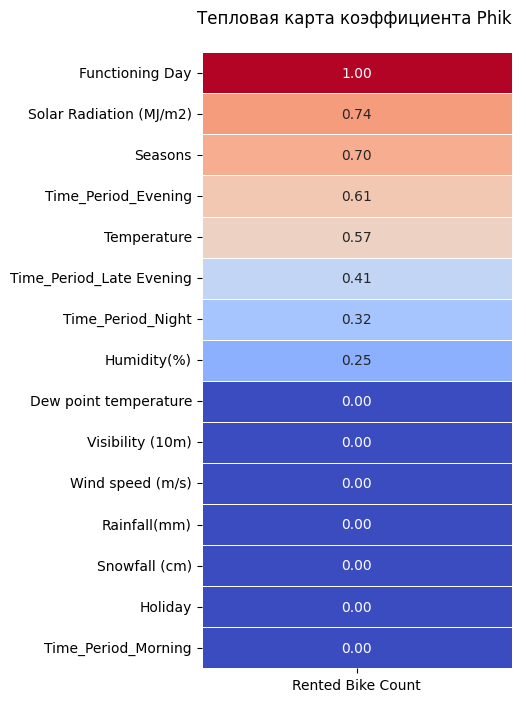

In [117]:
phik_coolwarm_matrix(df=df_train, target_var='Rented Bike Count', interval_cols=numerical_features, matrix_view=False, figsize=(4, 8))

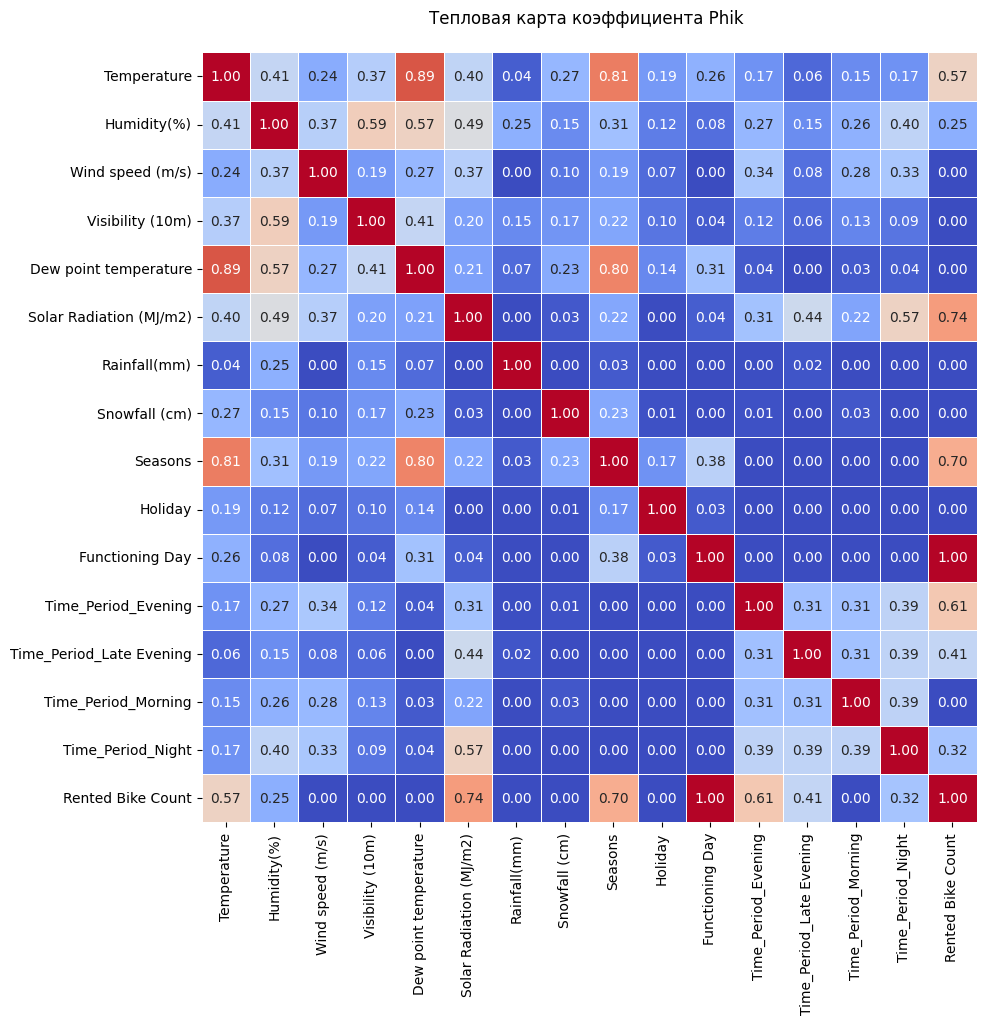

In [127]:
phik_coolwarm_matrix(df=df_train, target_var='Rented Bike Count', interval_cols=numerical_features, matrix_view=True, figsize=(10, 10))

## Комментарий по EDA
___

## Шаг 2. Разделение данных на тренировочную и валидационную выборки

In [ ]:
X_train_val = df_train_optimized.drop(columns='rented_bike_count')
X_test = df_test_optimized.drop(columns='rented_bike_count')

y_train_val = df_train_optimized['rented_bike_count']
y_test = df_test_optimized['rented_bike_count']

print('Размер обучающей выборки', X_train_val.shape)
print('Размер целевой переменной обучающей выборки', y_train_val.shape)
print('Размер тестовой выборки', X_test.shape)
print('Размер целевой переменной тестовой выборки', y_test.shape)

Размер обучающей выборки (7008, 15)
Размер целевой переменной обучающей выборки (7008,)
Размер тестовой выборки (1752, 15)
Размер целевой переменной тестовой выборки (1752,)


## Комментарий по разбиению выборки
___

## Шаг 3. Обучение новых моделей